Conclusion #2:

Hypothesis test used to interpret conclusion #2:
Does taking a prep course improve math grades?


Null: There is no differnce in mean math scores between students that completed the math course and the ones who did.


Alternative: Students who completed the test prep have higher mean math scored.

In [3]:

pip install pandas numpy seaborn matplotlib scipy

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ----------------- ---------------------- 4.2/9.7 MB 22.6 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.7 MB 22.1 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 20.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------- ----------------------------- 3.1/12.3 MB 15.4 MB/s eta 0:00:01
   ---------------------- ----------------- 7.1/12.3 MB 17.3 MB/s eta 0:00:01
   ---------------------------------- ----- 10.7/12.3 MB 17.3 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 16.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------------- -------------------- 3.9/8.1 MB 19.7 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 19.1 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 18.1 MB/s eta 0:00:00
   -------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Code 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

# Rename some columns with a better description
df = df.rename(columns = {
    "race/ethnicity": "race",
    "lunch": "lunch_plan",
    "test_preparation_course": "test_prep_status"
})
df.head()

,gender,race,parental_level_of_education,lunch_plan,test_prep_status,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
df.dtypes
categorical_columns = [
    "gender", "race", "parental_level_of_education", 
    "lunch_plan", "test_prep_status"
]

for col in categorical_columns:
    df[col] = df[col].astype("category")

df.dtypes

gender                         category
race                           category
parental_level_of_education    category
lunch_plan                     category
test_prep_status               category
math_score                        int64
reading_score                     int64
writing_score                     int64
dtype: object

In [11]:
from scipy.stats import ttest_ind
#first seperate the non test prep and test prep students 
completed = df[df['test_prep_status'] == 'completed']['math_score']
none= df[df['test_prep_status'] == 'none']['math_score']

#t-test
stat, p=ttest_ind(completed, none)

print('p-value:', p)

if p< 0.05: 
    print("reject null hypothesis: Test prep does affect math scores")
else: 
    print('fail to reject null hypothesis')

p-value: 1.5359134607147448e-08
reject null hypothesis: Test prep does affect math scores


C:\Users\Tibeb\AppData\Local\Temp\ipykernel_1992\3494032876.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='test_prep_status', y='math_score', palette='coolwarm')


Text(0, 0.5, 'Math score')

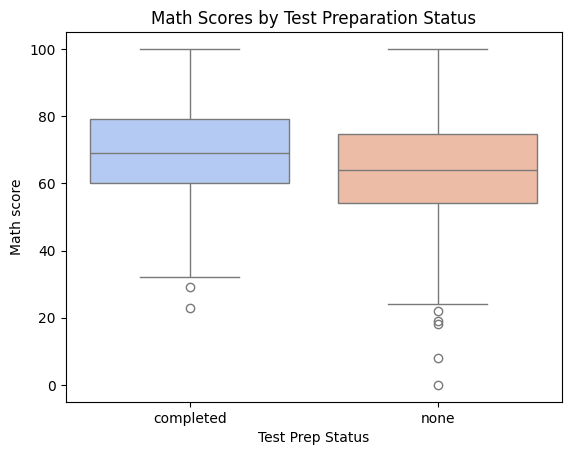

In [13]:
sns.boxplot(data=df, x='test_prep_status', y='math_score', palette='coolwarm')
plt.title("Math Scores by Test Preparation Status")
plt.xlabel("Test Prep Status")
plt.ylabel('Math score')